# Тестирование реализации на наборе MNIST

## Загрузка данных

В данном блокноте проведём тестирование собственной реализации, а также сравнение её по основным параметрам: ошибка, точность, скорость выполнения и потребление память с реализацией, предоставленной в библиотеке sklearn 

Также визуализируем полученные результаты и опишем их


Загружаем все необходимые модули для дальнейшего

In [1]:
from tsne import tsne

import numpy as np
import matplotlib.pyplot as plt
import time
import os
import psutil
from matplotlib.colors import ListedColormap

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

Загружаем в переменную X набор MNIST (содержит данные о 2500 рукописных цифрах отрисованных на 784 пикселях)

labels - набор самих цифр

In [2]:
X = np.loadtxt("mnist2500_X.txt")
labels = np.loadtxt("mnist2500_labels.txt")

## Сравнение по времени, потреблению памяти и ошибке

In [3]:
process = psutil.Process(os.getpid())
start_time = time.time()
start_memory = process.memory_info().rss

Y = tsne(X) 

end_time = time.time()
end_memory = process.memory_info().rss

execution_time = end_time - start_time
memory_used_mb = (end_memory - start_memory) / (1024 * 1024)
total_memory_mb = end_memory / (1024 * 1024)

print(f"\nВремя выполнения: {execution_time:.2f} сек.")
print(f"Прирост памяти во время t-SNE: {memory_used_mb:.2f} MB")
print(f"Итоговое потребление памяти процессом: {total_memory_mb:.2f} MB")

Среднее значение sigma: 1.819611
Итерация 1000: значение функции потерь (KL) = 0.973096

Время выполнения: 424.25 сек.
Прирост памяти во время t-SNE: 10.85 MB
Итоговое потребление памяти процессом: 238.25 MB


In [4]:
process = psutil.Process(os.getpid())
start_time = time.time()
start_memory = process.memory_info().rss

pca_transformer = PCA(n_components=50)
X_reduced = pca_transformer.fit_transform(X)

tsne_transformer = TSNE(n_components=2,         
    perplexity=30.0,         
    learning_rate=500.0,
    max_iter=1000)
Y_sklearn = tsne_transformer.fit_transform(X_reduced)

end_time = time.time()
end_memory = process.memory_info().rss

execution_time = end_time - start_time
memory_used_mb = (end_memory - start_memory) / (1024 * 1024)
total_memory_mb = end_memory / (1024 * 1024)

print(f"Значение функции потерь (KL) = {tsne_transformer.kl_divergence_:.4f}")

print(f"\nВремя выполнения: {execution_time:.2f} сек.")
print(f"Прирост памяти во время t-SNE: {memory_used_mb:.2f} MB")
print(f"Итоговое потребление памяти процессом: {total_memory_mb:.2f} MB")

Значение функции потерь (KL) = 1.1038

Время выполнения: 37.18 сек.
Прирост памяти во время t-SNE: 5.98 MB
Итоговое потребление памяти процессом: 244.29 MB


Что видим:

1) Ошибка (дивергенция Кульбека-Лейблера) в моей реализации получается ниже на 0.1-0.2, что говорит о лучшей минимизации ошибки, следовательно, лучшее качество отображения высокомерного пространства в маломерное.
2) Время моей реализации выше в 10+ раз. Объясняется тем, что в sklearn реализована ускоренная версия t-SNE: Burnes Hut t-SNE
3) По потреблению памяти во время t-SNE и за весь процесс находятся в одинаковых пределах, регулируется это больше работой самого процессора и Jupyter Notebook

## Сравнение при помощи KNN-Accuracy

В чём заключается идея этого исследования?

Наша задача была разделить точки по кластерам - одинаковые рядом с одинаковые. Теперь мы возьмём и обучим модель на этих данных и посмотрим как KNN (которая смотрит как раз таки на ближайших своих соседей) классифицирует эти точки. Чем была лучше класстеризация t-SNE - тем больше будет точность разделения по классам при помощи KNN.

In [5]:
def check_accuracy(Y_coords, labels):
    
    X_train, X_test, y_train, y_test = train_test_split(
        Y_coords, labels, test_size=0.2, stratify=labels
    )
    knn = KNeighborsClassifier(n_neighbors=30)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    return acc


acc_my = check_accuracy(Y, labels);
acc_sklearn = check_accuracy(Y_sklearn, labels);

print(f'Accuracy моей реализации: {acc_my*100:.2f}%')
print(f'Accuracy встроенной реализации: {acc_sklearn*100:.2f}%')

Accuracy моей реализации: 91.80%
Accuracy встроенной реализации: 89.00%


Что видим:

Accuracy моей реализации выше на 1-2%, что подтверждает то, что ошибка моей реализации ниже, чем у встроенной реализации. Разделение по классам в моей реализации лучше отображает данные, чем у встроенной

## Сравнение визуала

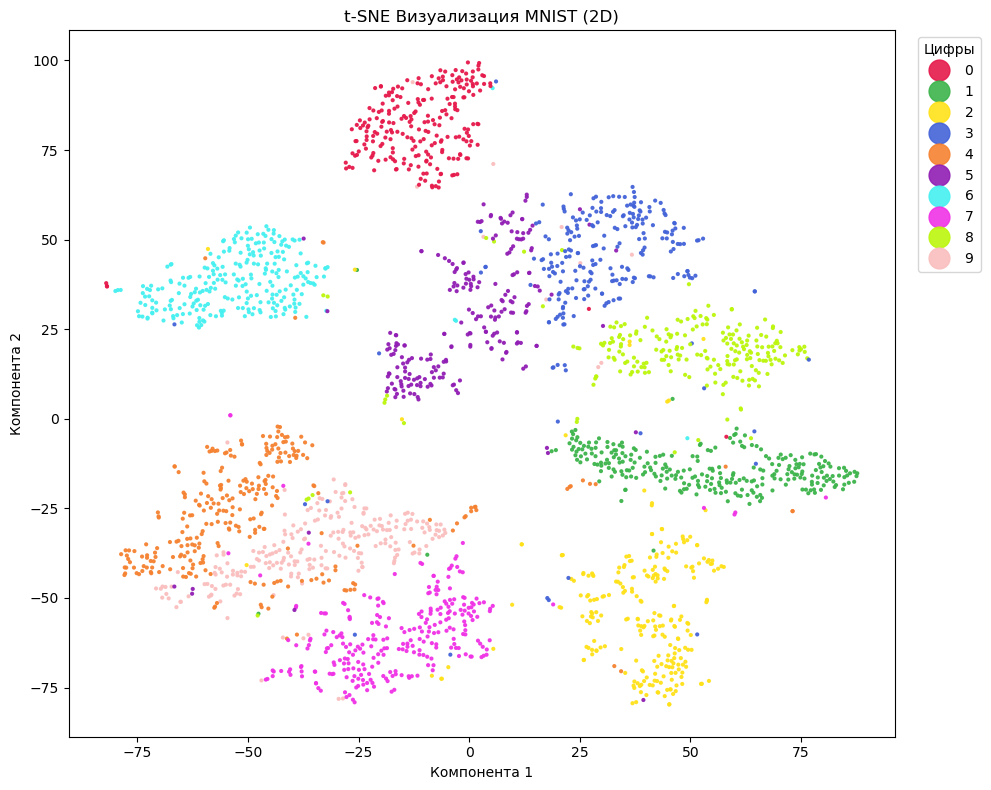

In [6]:
plt.figure(figsize=(10, 8))

high_contrast_colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', 
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe'
]

custom_cmap = ListedColormap(high_contrast_colors)

scatter = plt.scatter(Y[:, 0], Y[:, 1], s=4, c=labels, cmap=custom_cmap, alpha=0.9)

plt.legend(
    *scatter.legend_elements(num=10), 
    title="Цифры", 
    loc="upper left", 
    bbox_to_anchor=(1.02, 1),
    markerscale=2.5
)

plt.title("t-SNE Визуализация MNIST (2D)")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.tight_layout()
plt.show()

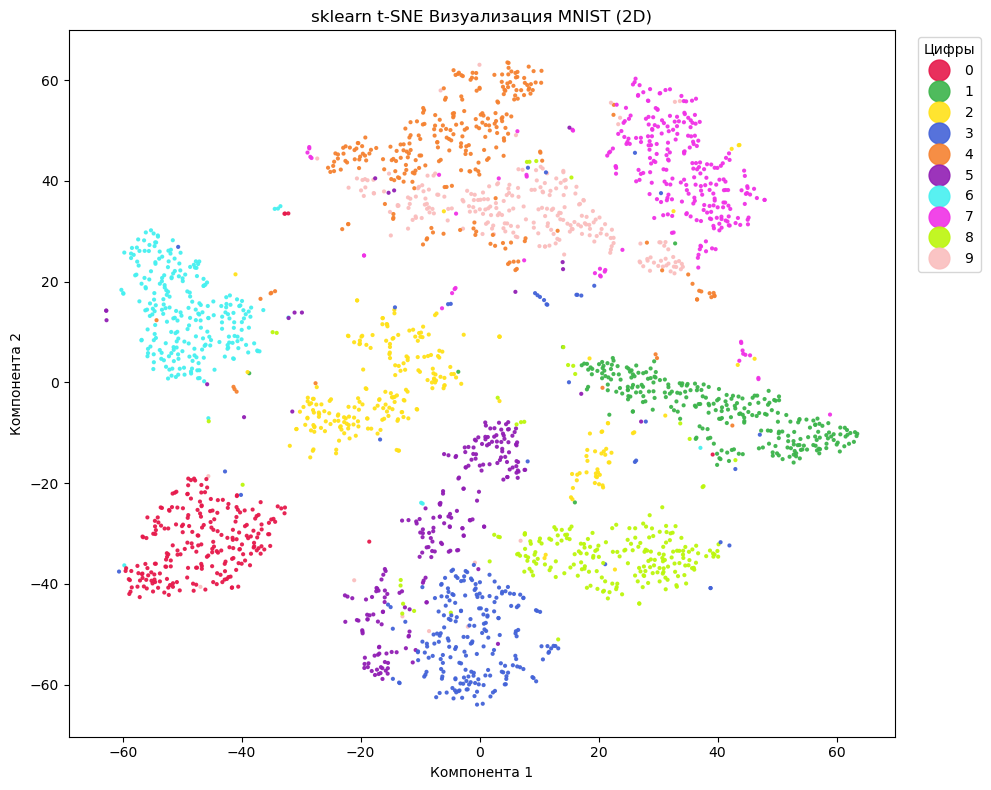

In [7]:
plt.figure(figsize=(10, 8))

high_contrast_colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', 
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe'
]

custom_cmap = ListedColormap(high_contrast_colors)

scatter = plt.scatter(Y_sklearn[:, 0], Y_sklearn[:, 1], s=4, c=labels, cmap=custom_cmap, alpha=0.9)

plt.legend(
    *scatter.legend_elements(num=10), 
    title="Цифры", 
    loc="upper left", 
    bbox_to_anchor=(1.02, 1),
    markerscale=2.5
)

plt.title("sklearn t-SNE Визуализация MNIST (2D)")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.tight_layout()
plt.show()

В целом, в моей реализации мы видим определённые кластеры с каким-то расстоянием, что и подверждает высокое Accuracy.

Во втором случае всё аналогичным образом, но можно выделить наслоение некоторых слоёв друг на друга и разрыв некоторых классов.